# Cell 1 _ Importing libraries & device setups

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Using devices: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch version: 2.11.0+cu128
Using devices: cuda
GPU: Tesla T4


# Cell 2 _ Downloading & preparing the dataset

In [4]:
# Download from Microsoft
!wget -q --show-progress "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip" -O /content/cats_dogs.zip

with zipfile.ZipFile('/content/cats_dogs.zip', 'r') as z:
  z.extractall('/content/cats_dogs_raw')

print("Done!")
print(os.listdir('/content/cats_dogs_raw'))

/content/cats_dogs. 100%[===================>] 786.67M   229MB/s    in 3.4s    
Done!
['PetImages', 'CDLA-Permissive-2.0.pdf', 'readme[1].txt']


# Cell 3 _ Cleaning corrupted images & building folder structure with format aware corruption detect

In [5]:
import imghdr

source_dir = '/content/cats_dogs_raw/PetImages'

# Valid image format that are accepted
VALID_FORMATS = {'jpeg', 'png', 'bmp', 'gif', 'tiff', 'webp', 'jpg', 'PSD', 'JPEG'}

corrupted_files = []
format_counts = {}

for category in ['Cat', 'Dog']:
  folder = os.path.join(source_dir, category)
  for fname in os.listdir(folder):
    fpath = os.path.join(folder, fname)
    is_corrupted = False
    reason = ''

    # Check 1 - what format is it actually?-----------------------------------------
    try:
      file_type = imghdr.what(fpath)
      format_counts[file_type] = format_counts.get(file_type, 0) + 1

      if file_type is None:
        is_corrupted = True
        reason = 'Unrecognizable file format(not an image)'

      elif file_type not in VALID_FORMATS:
        is_corrupted = True
        reason = f"Unsupported format: {file_type}"

    except Exception as e:
      is_corrupted = True
      reason = f"imghdr error: {e}"

    # Check 2 _ can PIL actually open & verify it?
    if not is_corrupted:
      try:
        img = Image.open(fpath)
        img.verify()
      except Exception as e:
        is_corrupted = True
        reason = f"PIL verify failed: {e}"

    if is_corrupted:
      corrupted_files.append((fpath, category, fname, reason))

# Show format ditribution
print("Format distribution across all files:")
for fmt, count in sorted(format_counts.items(), key=lambda x: -x[1]):
  label = " ACCEPTED" if fmt in VALID_FORMATS else "REJECTED"
  print(f" {str(fmt):10s}: {count:5d} files {label}")

print(f"\nTotal corrupted: {len(corrupted_files)} files")
print("\nCorrupted file details:")
for fpath, cat, fname, reason in corrupted_files[:]:
  size_kb = os.path.getsize(fpath) / 1024
  print(f" [{cat}] {fname}: {size_kb:.1f}KB - {reason}")

/tmp/ipykernel_1119/2152717672.py:1: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Format distribution across all files:
 jpeg      : 24744 files  ACCEPTED
 bmp       :   173 files  ACCEPTED
 gif       :    51 files  ACCEPTED
 None      :    30 files REJECTED
 png       :     4 files  ACCEPTED

Total corrupted: 30 files

Corrupted file details:
 [Cat] 1476.jpg: 27.5KB - Unrecognizable file format(not an image)
 [Cat] 4165.jpg: 81.5KB - Unrecognizable file format(not an image)
 [Cat] 1483.jpg: 38.9KB - Unrecognizable file format(not an image)
 [Cat] 11196.jpg: 28.6KB - Unrecognizable file format(not an image)
 [Cat] 7245.jpg: 26.8KB - Unrecognizable file format(not an image)
 [Cat] 7441.jpg: 43.5KB - Unrecognizable file format(not an image)
 [Cat] 3089.jpg: 44.2KB - Unrecognizable file format(not an image)
 [Cat] Thumbs.db: 4079.3KB - Unrecognizable file format(not an image)
 [Cat] 666.jpg: 0.0KB - Unrecognizable file format(not an image)
 [Cat] 8335.jpg: 86.8KB - Unrecognizable file format(not an image)
 [Cat] 10404.jpg: 957.4KB - Unrecognizable file format(not an im


Sample BMP files (should look like normal cats/dogs):


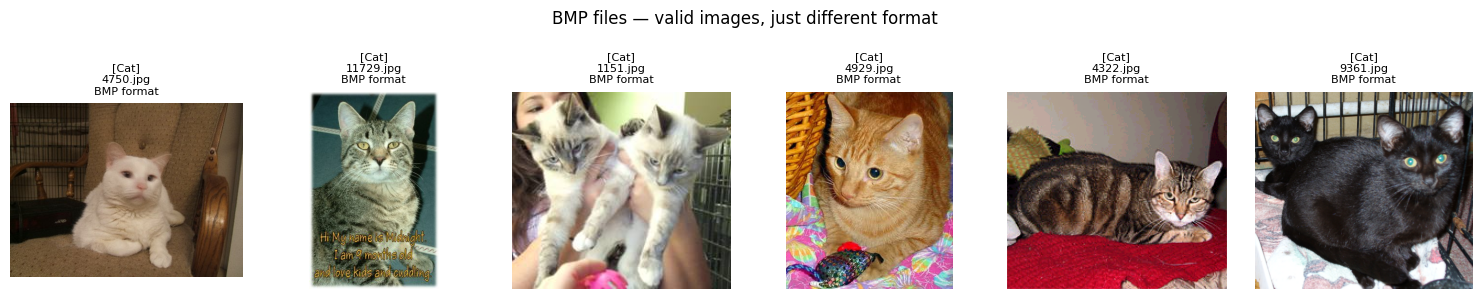

In [6]:
# Visualize a few BMP files to confirm they're real images ─────────────
print("\nSample BMP files (should look like normal cats/dogs):")

bmp_files = []
for category in ['Cat', 'Dog']:
    folder = os.path.join(source_dir, category)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if imghdr.what(fpath) == 'bmp':
            bmp_files.append((fpath, category, fname))
        if len(bmp_files) >= 6:
            break
    if len(bmp_files) >= 6:
        break

if bmp_files:
    fig, axes = plt.subplots(1, min(6, len(bmp_files)), figsize=(15, 3))
    if len(bmp_files) == 1:
        axes = [axes]
    for i, (fpath, category, fname) in enumerate(bmp_files[:6]):
        img = Image.open(fpath).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(f"[{category}]\n{fname}\nBMP format", fontsize=8)
        axes[i].axis('off')
    plt.suptitle('BMP files — valid images, just different format')
    plt.tight_layout()
    plt.show()
else:
    print("No BMP files found")

In [7]:
# ── Remove only truly corrupted files ────────────────────────────────────
removed = 0
for fpath, category, fname, reason in corrupted_files:
    size_kb = os.path.getsize(fpath) / 1024
    print(f"Removing [{category}] {fname} ({size_kb:.1f} KB) — {reason}")
    try:
        os.remove(fpath)
        removed += 1
    except Exception as e:
        print(f"  Could not remove: {e}")

print(f"\nRemoved {removed} genuinely corrupted files")
print(f"Cat images remaining: {len(os.listdir(os.path.join(source_dir, 'Cat')))}")
print(f"Dog images remaining: {len(os.listdir(os.path.join(source_dir, 'Dog')))}")

Removing [Cat] 1476.jpg (27.5 KB) — Unrecognizable file format(not an image)
Removing [Cat] 4165.jpg (81.5 KB) — Unrecognizable file format(not an image)
Removing [Cat] 1483.jpg (38.9 KB) — Unrecognizable file format(not an image)
Removing [Cat] 11196.jpg (28.6 KB) — Unrecognizable file format(not an image)
Removing [Cat] 7245.jpg (26.8 KB) — Unrecognizable file format(not an image)
Removing [Cat] 7441.jpg (43.5 KB) — Unrecognizable file format(not an image)
Removing [Cat] 3089.jpg (44.2 KB) — Unrecognizable file format(not an image)
Removing [Cat] Thumbs.db (4079.3 KB) — Unrecognizable file format(not an image)
Removing [Cat] 666.jpg (0.0 KB) — Unrecognizable file format(not an image)
Removing [Cat] 8335.jpg (86.8 KB) — Unrecognizable file format(not an image)
Removing [Cat] 10404.jpg (957.4 KB) — Unrecognizable file format(not an image)
Removing [Cat] 2101.jpg (34.9 KB) — Unrecognizable file format(not an image)
Removing [Cat] 6438.jpg (31.2 KB) — Unrecognizable file format(not an im

In [8]:
# ── Split into train/val/test ─────────────────────────────────────────────
import random
import shutil
random.seed(42)

output_dir = '/content/cats_dogs_split'
for split in ['train', 'val', 'test']:
    for cls in ['cats', 'dogs']:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

def split_images(src_folder, class_name, train_pct=0.8, val_pct=0.1):
    images = os.listdir(src_folder)
    random.shuffle(images)
    total     = len(images)
    train_end = int(total * train_pct)
    val_end   = int(total * (train_pct + val_pct))

    splits = {
        'train': images[:train_end],
        'val':   images[train_end:val_end],
        'test':  images[val_end:]
    }

    for split_name, files in splits.items():
        dest = os.path.join(output_dir, split_name, class_name)
        for f in files:
            shutil.copy(os.path.join(src_folder, f),
                        os.path.join(dest, f))

    print(f"{class_name}: {len(splits['train'])} train | "
          f"{len(splits['val'])} val | {len(splits['test'])} test")

split_images(os.path.join(source_dir, 'Cat'), 'cats')
split_images(os.path.join(source_dir, 'Dog'), 'dogs')
print("\nSplit complete!")

cats: 9987 train | 1248 val | 1249 test
dogs: 9990 train | 1249 val | 1249 test

Split complete!


# Cell 4 _ Building a custom dataset class

In [9]:
class CatsDogsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.classes   = ['cats', 'dogs']
        self.class_to_idx = {'cats': 0, 'dogs': 1}

        # Build list of (image_path, label) pairs
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            label     = self.class_to_idx[class_name]
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append(
                        (os.path.join(class_dir, fname), label)
                    )

    def __len__(self):
        # Required — tells DataLoader how many samples exist
        return len(self.samples)

    def __getitem__(self, idx):
        # Required — loads and returns one sample by index
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            # Return a black image if file is corrupted
            img = Image.new('RGB', (224, 224))

        if self.transform:
            img = self.transform(img)

        return img, label

print("CatsDogsDataset class defined!")

CatsDogsDataset class defined!


# Define transforms & create DataLoaders

In [10]:
IMG_SIZE   = 224   # ResNet50's expected input size
BATCH_SIZE = 32

# Training transforms — with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/test transforms — no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = CatsDogsDataset(
    os.path.join(output_dir, 'train'),
    transform=train_transforms
)
val_dataset = CatsDogsDataset(
    os.path.join(output_dir, 'val'),
    transform=val_transforms
)
test_dataset = CatsDogsDataset(
    os.path.join(output_dir, 'test'),
    transform=val_transforms
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

# Verify a batch loads correctly
imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape: {imgs.shape}")
print(f"Batch label shape: {labels.shape}")
print(f"Labels in batch: {labels[:8].tolist()}")

Train samples: 19977
Val samples:   2497
Test samples:  2498

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Labels in batch: [1, 0, 1, 0, 1, 0, 1, 1]


# Cell 6 _ Loading pretrained ResNet50 & modifying for binary classification


In [11]:
# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
# ResNet50's fc layer: Linear(2048, 1000) — 1000 ImageNet classes
# We replace it with: Linear(2048, 1) — binary cat/dog
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1)   # single output for binary classification
)

model = model.to(device)

# Count frozen vs trainable parameters
frozen     = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen parameters:    {frozen:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"\nModified fc layer:\n{model.fc}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


Frozen parameters:    23,508,032
Trainable parameters: 524,801

Modified fc layer:
Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=256, out_features=1, bias=True)
)


# Cell 7 _ Training & evaluation functions

In [12]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

def train_epoch(model, loader, optimizer, criterion, device):
  model.train()
  total_loss = 0.0
  correct    = 0
  total      = 0

  for imgs, labels in loader:
    imgs   = imgs.to(device)
    labels = labels.float().to(device)  # BCEWithLogitsLoss needs float


    optimizer.zero_grad()
    outputs = model(imgs).squeeze(1)    # (batch, 1) -> (batch,)
    loss    = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    preds       = (torch.sigmoid(outputs) > 0.5).float()
    correct     = (preds == labels).sum().item()
    total       = labels.size(0)

  return total_loss / len(loader), 100 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs    = imgs.to(device)
            labels  = labels.float().to(device)
            outputs = model(imgs).squeeze(1)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = (torch.sigmoid(outputs) > 0.5).float()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    # Guard against empty loader
    if total == 0:
        return 0.0, 0.0

    return total_loss / len(loader), 100 * correct / total

print("Loss, optimizer, and training functions are ready!!!")



Loss, optimizer, and training functions are ready!!!


# Cell 8 _ Phase 1 training (frozen backbone)

In [13]:
EPOCHS_PHASE1 = 10
best_val_acc  = 0.0
history       = {'train_loss': [], 'train_acc': [],
                 'val_loss':   [], 'val_acc':   []}

print("Phase 1 — training classification head only (frozen ResNet50)")
print("="*60)

for epoch in range(EPOCHS_PHASE1):
    train_loss, train_acc = train_epoch(model, train_loader,
                                         optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_cats_dogs.pth')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS_PHASE1} | "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | "
          f"Best: {best_val_acc:.2f}%")

print(f"\nPhase 1 complete! Best val accuracy: {best_val_acc:.2f}%")

Phase 1 — training classification head only (frozen ResNet50)
Epoch  1/10 | Train: 100.00% | Val: 97.88% | Best: 97.88%
Epoch  2/10 | Train: 100.00% | Val: 97.00% | Best: 97.88%
Epoch  3/10 | Train: 100.00% | Val: 98.64% | Best: 98.64%
Epoch  4/10 | Train: 100.00% | Val: 98.56% | Best: 98.64%
Epoch  5/10 | Train: 100.00% | Val: 97.92% | Best: 98.64%
Epoch  6/10 | Train: 100.00% | Val: 98.28% | Best: 98.64%
Epoch  7/10 | Train: 100.00% | Val: 98.48% | Best: 98.64%
Epoch  8/10 | Train: 88.89% | Val: 98.68% | Best: 98.68%
Epoch  9/10 | Train: 100.00% | Val: 98.72% | Best: 98.72%
Epoch 10/10 | Train: 100.00% | Val: 98.56% | Best: 98.72%

Phase 1 complete! Best val accuracy: 98.72%


# Cell 9 _ Phase 2: Unfreezing & fine-tuning

In [15]:
# Unfreeze layer4 and fc (last ResNet block + classifier head)
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

# Recompile with lower LR and all trainable parameters
optimizer_phase2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)
scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2, mode='max', factor=0.5, patience=3
)

trainable_now = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
print(f"Trainable parameters after unfreezing: {trainable_now:,}")
print("\nPhase 2 — fine-tuning layer4 + fc")
print("="*60)

EPOCHS_PHASE2 = 10

for epoch in range(EPOCHS_PHASE2):
    train_loss, train_acc = train_epoch(model, train_loader,
                                         optimizer_phase2,
                                         criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler_phase2.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_cats_dogs.pth')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS_PHASE2} | "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | "
          f"Best: {best_val_acc:.2f}%")

print(f"\nPhase 2 complete! Best val accuracy: {best_val_acc:.2f}%")

Trainable parameters after unfreezing: 15,489,537

Phase 2 — fine-tuning layer4 + fc
Epoch  1/10 | Train: 100.00% | Val: 98.84% | Best: 98.84%
Epoch  2/10 | Train: 100.00% | Val: 98.80% | Best: 98.84%
Epoch  3/10 | Train: 100.00% | Val: 98.96% | Best: 98.96%
Epoch  4/10 | Train: 100.00% | Val: 98.88% | Best: 98.96%
Epoch  5/10 | Train: 100.00% | Val: 98.96% | Best: 98.96%
Epoch  6/10 | Train: 100.00% | Val: 98.84% | Best: 98.96%
Epoch  7/10 | Train: 77.78% | Val: 98.92% | Best: 98.96%
Epoch  8/10 | Train: 100.00% | Val: 98.88% | Best: 98.96%
Epoch  9/10 | Train: 100.00% | Val: 99.12% | Best: 99.12%
Epoch 10/10 | Train: 100.00% | Val: 99.04% | Best: 99.12%

Phase 2 complete! Best val accuracy: 99.12%


# Cell 10 _ Final evaluation & plots

Final test accuracy: 99.48%


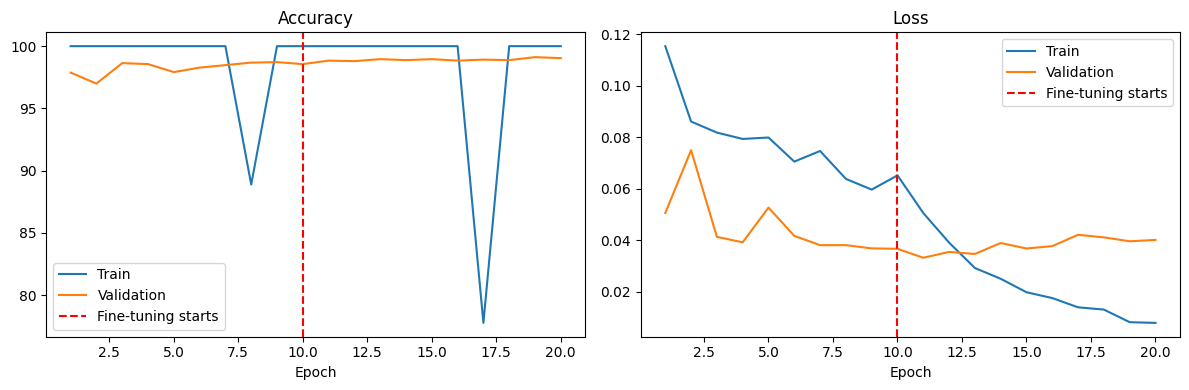

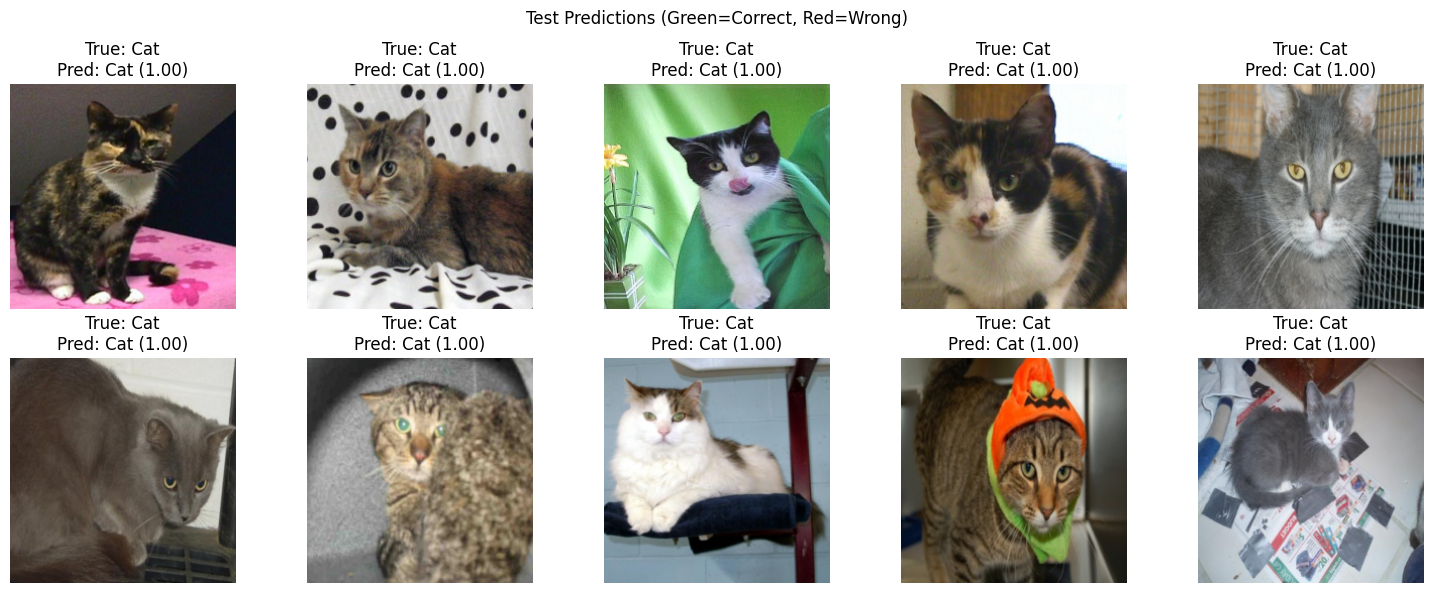

In [22]:
# Load best weights
model.load_state_dict(torch.load('/content/best_cats_dogs.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final test accuracy: {test_acc:.2f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history['train_acc']) + 1)
phase1_end   = EPOCHS_PHASE1

ax1.plot(epochs_range, history['train_acc'], label='Train')
ax1.plot(epochs_range, history['val_acc'],   label='Validation')
ax1.axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tuning starts')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs_range, history['train_loss'], label='Train')
ax2.plot(epochs_range, history['val_loss'],   label='Validation')
ax2.axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tuning starts')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/pytorch_cats_dogs_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Show some predictions
model.eval()
imgs, labels = next(iter(test_loader))
imgs_gpu = imgs.to(device)
with torch.no_grad():
    outputs = model(imgs_gpu).squeeze(1)
    probs   = torch.sigmoid(outputs).cpu().numpy()
    preds   = (probs > 0.5).astype(int)

# Denormalize images for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img = imgs[i].permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    img = img * std + mean                   # denormalize
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = 'Dog' if labels[i] == 1 else 'Cat'
    pred_label = 'Dog' if preds[i] == 1 else 'Cat'
    color = 'green' if true_label == pred_label else 'red'
    confidence = probs[i] if preds[i] == 1 else 1 - probs[i]
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})")
    ax.axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.savefig('/content/pytorch_cats_dogs_predictions.png', dpi=150)
plt.show()